In [ ]:
# Instalação das bibliotecas necessárias

!pip install -r requirements.txt

In [3]:
# Importação das bibliotecas

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm

# Configurações do ambiente
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [4]:
# Leitura do dataset

data_df = pd.read_csv("./datasets/heart_failure_clinical_records_dataset.csv")
data_df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
# Análise exploratória dos dados

print("--- Informações do Dataset ---")
data_df.info()

print("\n--- Estatísticas Descritivas ---")
display(data_df.describe().T)

print("\n--- Valores Nulos ---")
print(data_df.isnull().sum())

--- Informações do Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 K

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0



--- Valores Nulos ---
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


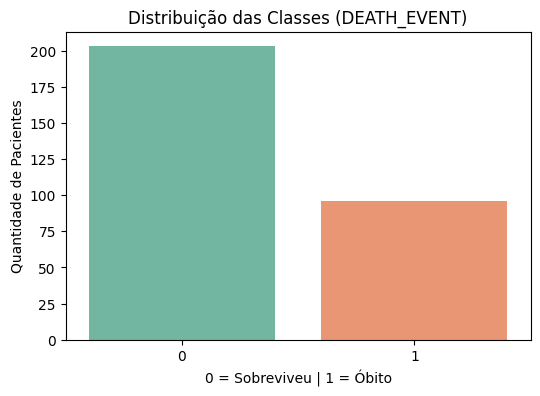

In [15]:
# Visualização da Distribuição das variáveis

plt.figure(figsize=(6, 4))
sns.countplot(x="DEATH_EVENT", data=data_df, palette="Set2")

plt.title("Distribuição das Classes (DEATH_EVENT)")
plt.xlabel("0 = Sobreviveu | 1 = Óbito")
plt.ylabel("Quantidade de Pacientes")
plt.show()

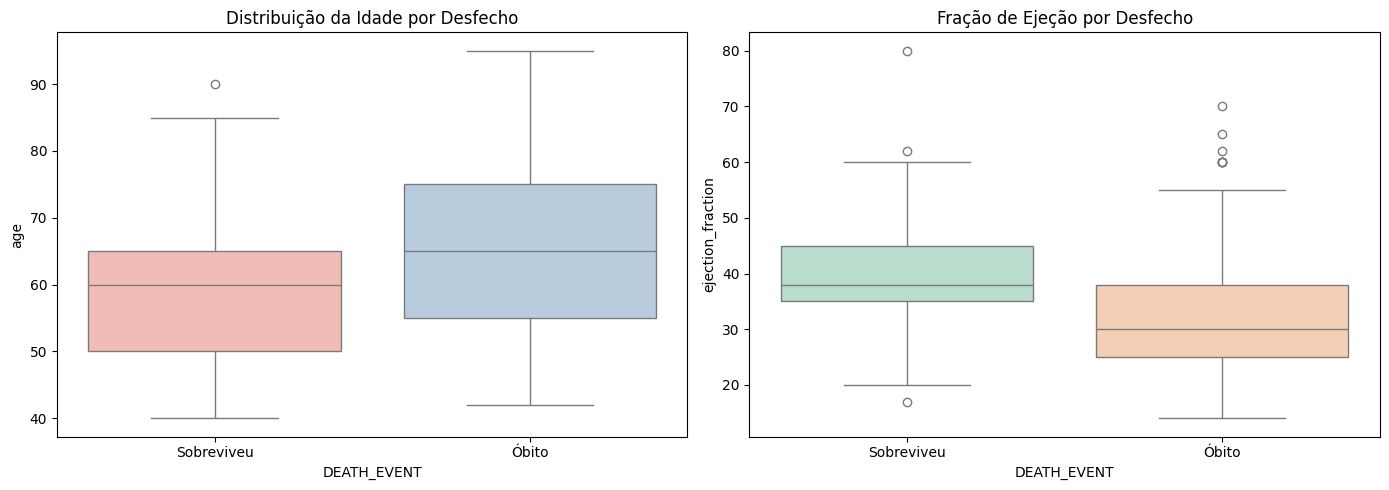

In [16]:
# Visualização da Distribuição de Idade e Fração de Ejeção por Desfecho

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Idade por evento de morte
sns.boxplot(ax=axes[0], x="DEATH_EVENT", y="age", data=data_df, palette="Pastel1")
axes[0].set_title("Distribuição da Idade por Desfecho")
axes[0].set_xticklabels(["Sobreviveu", "Óbito"])

# Gráfico 2: Fração de Ejeção por evento de morte
sns.boxplot(
    ax=axes[1], x="DEATH_EVENT", y="ejection_fraction", data=data_df, palette="Pastel2"
)
axes[1].set_title("Fração de Ejeção por Desfecho")
axes[1].set_xticklabels(["Sobreviveu", "Óbito"])

plt.tight_layout()
plt.show()

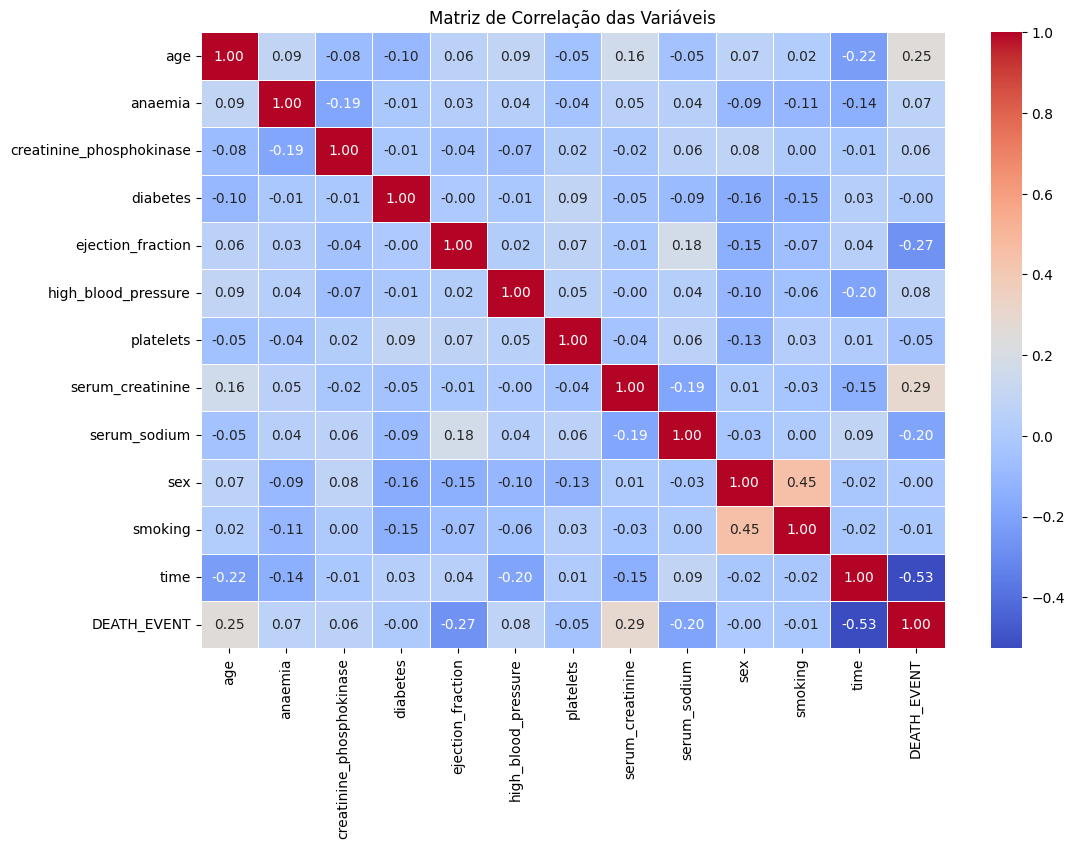

In [11]:
# Visualização da Matriz de Correlação

plt.figure(figsize=(12, 8))
# Calcula a correlação entre as variáveis
correlation_matrix = data_df.corr()

# Desenha o mapa de calor (heatmap)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação das Variáveis")
plt.show()

In [7]:
# Pré processamento e separação dos dados

X = data_df.drop(["DEATH_EVENT"], axis=1)
y = data_df["DEATH_EVENT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=25
)

print(f"Formato dos dados de treino: {X_train.shape}")
print(f"Formato dos dados de teste: {X_test.shape}")

Formato dos dados de treino: (209, 12)
Formato dos dados de teste: (90, 12)


In [8]:
# Normalização dos dados

s_scaler = preprocessing.StandardScaler()

X_train = s_scaler.fit_transform(X_train)
X_test = s_scaler.transform(X_test)

In [9]:
# Treinamento do modelo KNN

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [10]:
# Avaliação de métricas do modelo

knn_pred = knn_model.predict(X_test)

# Cálculo das métricas
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

# Exibição dos resultados
print(f"Acurácia:  {knn_accuracy:.4f}")
print(f"Precisão:  {knn_precision:.4f}")
print(f"Recall:    {knn_recall:.4f}")
print(f"F1-Score:  {knn_f1:.4f}")

print("\nRelatório de Classificação Completo:")
print(classification_report(y_test, knn_pred))

Acurácia:  0.7000
Precisão:  0.5789
Recall:    0.3667
F1-Score:  0.4490

Relatório de Classificação Completo:
              precision    recall  f1-score   support

           0       0.73      0.87      0.79        60
           1       0.58      0.37      0.45        30

    accuracy                           0.70        90
   macro avg       0.66      0.62      0.62        90
weighted avg       0.68      0.70      0.68        90



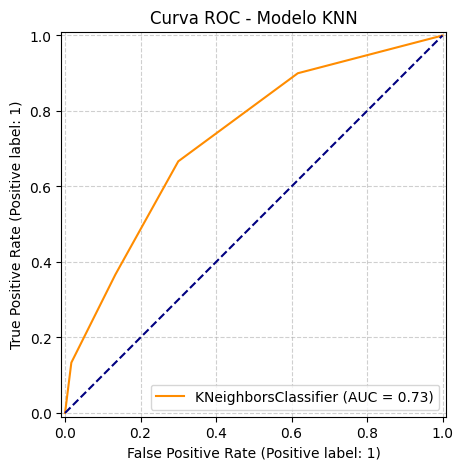

In [17]:
# Visualização da Curva ROC para o modelo KNN

from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(7, 5))
# Plota a curva ROC usando o modelo KNN treinado e os dados de teste
RocCurveDisplay.from_estimator(knn_model, X_test, y_test, ax=plt.gca(), color="darkorange")

# Linha de referência (modelo aleatório)
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")

plt.title("Curva ROC - Modelo KNN")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

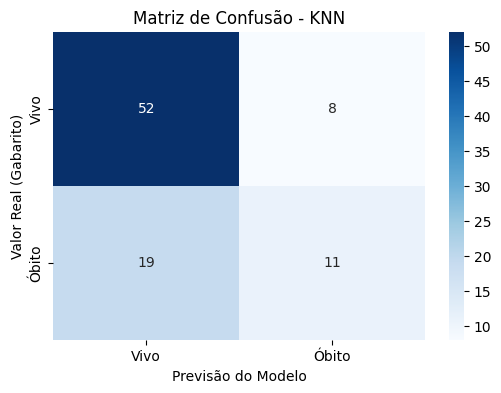

In [ ]:
# Geração da Matriz de Confusão

cm = confusion_matrix(y_test, knn_pred)

# Plota a matriz de forma visual
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Vivo", "Óbito"], 
            yticklabels=["Vivo", "Óbito"])

plt.xlabel("Previsão do Modelo")
plt.ylabel("Valor Real (Gabarito)")
plt.title("Matriz de Confusão - KNN")
plt.show()